# Customer Behavior Analysis — Alfido Tech
**Goal:** Analyze customer transactions & behavior to identify segments, purchase patterns, and churn risks.

**Dataset:** [Customer Behavior Analysis](https://www.kaggle.com/datasets/bhanupratapbiswas/customer-behavior-analysis) (Kaggle) — `ecommerce_customer_data_large.csv`, 250,000 transaction records across 49,661 customers, Jan 2020 – Sep 2023.

**Contents**
1. Setup & Data Loading
2. Data Cleaning
3. Feature Engineering (RFM + behavioral features)
4. RFM Scoring & Rule-Based Segmentation
5. K-Means Clustering (segmentation validation)
6. Segment Profiling
7. Purchase Pattern Visualizations
8. Retention & Cohort Analysis
9. Churn Risk Analysis
10. SQL Analysis Layer
11. Key Findings & Recommendations for Alfido Tech

*Author: [Your Name] — Data Analytics Internship Project*


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

RAW_PATH = "ecommerce_customer_data_large.csv"  # place the Kaggle CSV alongside this notebook
df_raw = pd.read_csv(RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (250000, 13)


In [2]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


In [3]:
df_raw.isna().sum()


## 2. Data Cleaning

Steps performed:
- Drop the duplicate `Customer Age` column (identical to `Age`).
- Parse `Purchase Date` to datetime.
- Fill missing `Returns` values with `0` (not marked as returned).
- Drop exact duplicate rows and rows with non-positive price/quantity/amount.
- Standardize text fields and column names.


In [4]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

assert (df["Age"] == df["Customer Age"]).all(), "Age columns are not identical"
df = df.drop(columns=["Customer Age"])

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Returns"] = df["Returns"].fillna(0).astype(int)

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

before = len(df)
df = df[(df["Product Price"] > 0) & (df["Quantity"] > 0) & (df["Total Purchase Amount"] > 0)]
print(f"Dropped {before - len(df)} rows with non-positive price/qty/amount")

df["Product Category"] = df["Product Category"].str.strip()
df["Payment Method"] = df["Payment Method"].str.strip()
df["Gender"] = df["Gender"].str.strip()

df = df.rename(columns={
    "Customer ID": "customer_id", "Purchase Date": "purchase_date",
    "Product Category": "category", "Product Price": "unit_price",
    "Quantity": "quantity", "Total Purchase Amount": "amount",
    "Payment Method": "payment_method", "Returns": "returned",
    "Customer Name": "customer_name", "Age": "age", "Gender": "gender", "Churn": "churn",
})
df["year_month"] = df["purchase_date"].dt.to_period("M").astype(str)

print("Clean shape:", df.shape)
df.head()


Dropped 0 duplicate rows
Dropped 0 rows with non-positive price/qty/amount
Clean shape: (250000, 13)


## 3. Feature Engineering — Customer-Level RFM & Behavioral Features

We aggregate the transaction log to one row per customer:
- **Recency** — days since last purchase (relative to the day after the dataset's last date)
- **Frequency** — number of transactions
- **Monetary** — total amount spent
- Plus: average order value, return rate, tenure, preferred category/payment method, age, gender, and the provided `churn` label.


In [5]:
snapshot_date = df["purchase_date"].max() + pd.Timedelta(days=1)

def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

cust = df.groupby("customer_id").agg(
    recency=("purchase_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("purchase_date", "count"),
    monetary=("amount", "sum"),
    first_purchase=("purchase_date", "min"),
    last_purchase=("purchase_date", "max"),
    avg_order_value=("amount", "mean"),
    return_rate=("returned", "mean"),
    preferred_category=("category", mode_or_first),
    preferred_payment=("payment_method", mode_or_first),
    age=("age", "first"),
    gender=("gender", "first"),
    customer_name=("customer_name", "first"),
    churn=("churn", "first"),
).reset_index()

cust["tenure_days"] = (cust["last_purchase"] - cust["first_purchase"]).dt.days
print("Customer-level table:", cust.shape)
cust.head()


Customer-level table: (49661, 15)


## 4. RFM Scoring & Rule-Based Segmentation

Each customer is scored 1–5 on Recency, Frequency, and Monetary value (quintiles, 5 = best),
then mapped to a business-friendly segment using standard RFM heuristics
(Champions, Loyal Customers, At Risk, Hibernating, etc.).


In [6]:
cust["R_score"] = pd.qcut(cust["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
cust["F_score"] = pd.qcut(cust["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
cust["M_score"] = pd.qcut(cust["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
cust["RFM_score"] = cust["R_score"].astype(str) + cust["F_score"].astype(str) + cust["M_score"].astype(str)

def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if f >= 4 and m >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New Customers"
    if r >= 3 and 2 <= f <= 3: return "Potential Loyalists"
    if r <= 2 and f >= 4 and m >= 4: return "Can't Lose Them"
    if r <= 2 and f >= 3: return "At Risk"
    if r <= 2 and f <= 2 and m <= 2: return "Hibernating / Lost"
    return "Need Attention"

cust["rfm_segment"] = cust.apply(rfm_segment, axis=1)
cust["rfm_segment"].value_counts()


## 5. K-Means Clustering (validation of the RFM segmentation)

Silhouette by k: {2: np.float64(0.44), 3: np.float64(0.348), 4: np.float64(0.365), 5: np.float64(0.33), 6: np.float64(0.323), 7: np.float64(0.302), 8: np.float64(0.275)}


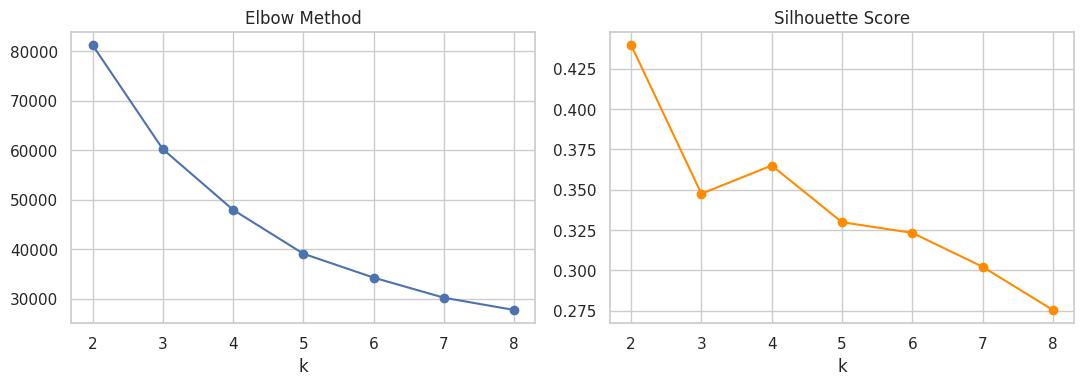

In [7]:
cluster_feats = cust[["recency", "frequency", "monetary"]].copy()
cluster_feats["frequency"] = np.log1p(cluster_feats["frequency"])
cluster_feats["monetary"] = np.log1p(cluster_feats["monetary"])
X = StandardScaler().fit_transform(cluster_feats)

inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias, marker="o"); axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k")
axes[1].plot(list(K_range), sils, marker="o", color="darkorange"); axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

print("Silhouette by k:", dict(zip(K_range, np.round(sils, 3))))


The silhouette score is technically maximized at **k = 2**, which mostly separates
"recently active" from "lapsed" customers — statistically valid, but too coarse
to act on. We use **k = 4** for cluster profiling below, since it yields more
actionable groups, while the rule-based RFM segmentation above (7 segments) remains
the primary segmentation used for the recommendations in Section 11.


In [8]:
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cust["cluster"] = km_final.fit_predict(X)

cluster_profile = cust.groupby("cluster").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    churn_rate=("churn", "mean"),
).round(2)
cluster_profile


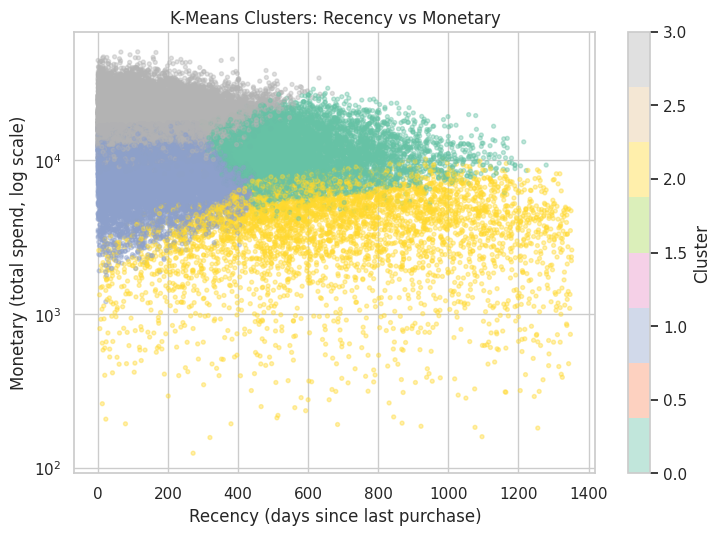

In [9]:
plt.figure(figsize=(7.5, 5.5))
sc = plt.scatter(cust["recency"], cust["monetary"], c=cust["cluster"], cmap="Set2", alpha=0.4, s=8)
plt.yscale("log")
plt.xlabel("Recency (days since last purchase)"); plt.ylabel("Monetary (total spend, log scale)")
plt.title("K-Means Clusters: Recency vs Monetary")
plt.colorbar(sc, label="Cluster")
plt.tight_layout(); plt.show()


## 6. Segment Profiling (RFM segments — primary segmentation)

In [10]:
segment_profile = cust.groupby("rfm_segment").agg(
    customers=("customer_id", "count"),
    avg_recency_days=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"),
    avg_order_value=("avg_order_value", "mean"),
    return_rate=("return_rate", "mean"),
    churn_rate=("churn", "mean"),
    avg_age=("age", "mean"),
).round(2)
segment_profile["pct_revenue"] = (100 * segment_profile["total_revenue"] / segment_profile["total_revenue"].sum()).round(1)
segment_profile.sort_values("total_revenue", ascending=False)


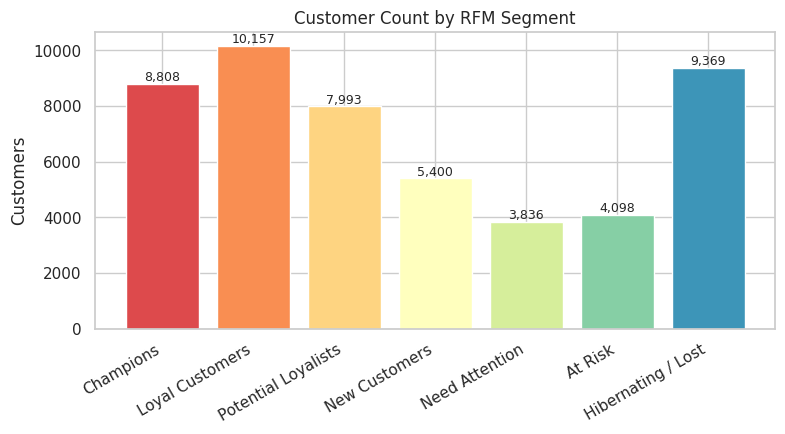

In [11]:
SEG_ORDER = ["Champions", "Loyal Customers", "Potential Loyalists", "New Customers", "Need Attention", "At Risk", "Hibernating / Lost"]
PALETTE = dict(zip(SEG_ORDER, sns.color_palette("Spectral", len(SEG_ORDER))))

seg_counts = cust["rfm_segment"].value_counts().reindex(SEG_ORDER)
plt.figure(figsize=(8, 4.5))
bars = plt.bar(seg_counts.index, seg_counts.values, color=[PALETTE[s] for s in seg_counts.index])
plt.title("Customer Count by RFM Segment"); plt.ylabel("Customers"); plt.xticks(rotation=30, ha="right")
for b, v in zip(bars, seg_counts.values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


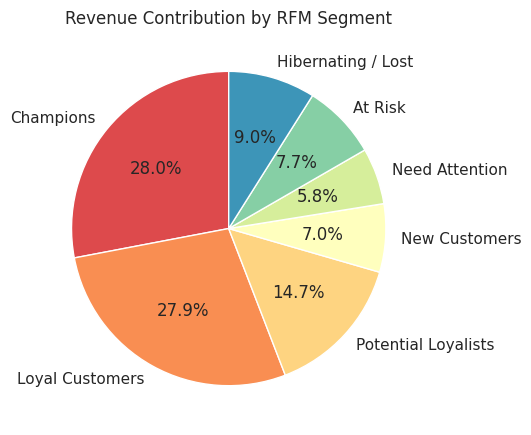

In [12]:
seg_rev = cust.groupby("rfm_segment")["monetary"].sum().reindex(SEG_ORDER)
plt.figure(figsize=(7, 4.5))
plt.pie(seg_rev.values, labels=seg_rev.index, autopct="%1.1f%%", startangle=90,
        colors=[PALETTE[s] for s in seg_rev.index], wedgeprops=dict(edgecolor="white"))
plt.title("Revenue Contribution by RFM Segment")
plt.tight_layout(); plt.show()


## 7. Purchase Pattern Visualizations

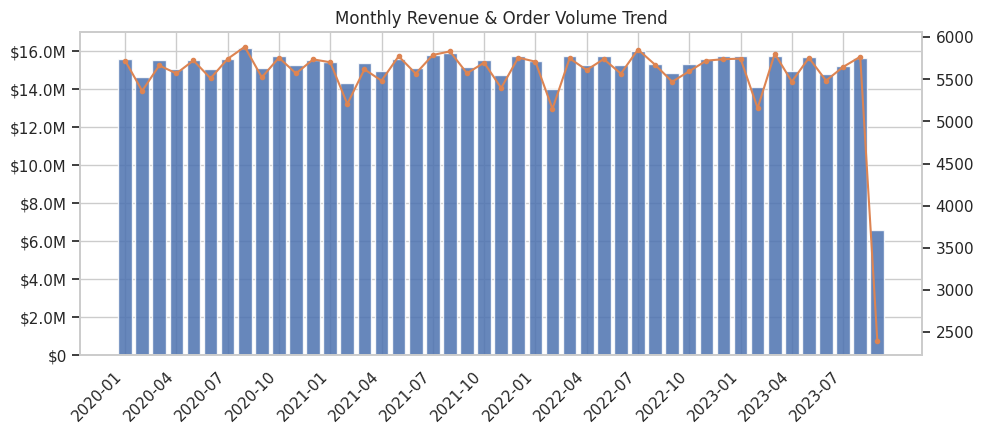

In [13]:
def money_fmt(x, pos):
    if x >= 1e6: return f"${x/1e6:.1f}M"
    if x >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"

monthly = df.groupby("year_month").agg(revenue=("amount", "sum"), orders=("amount", "count")).reset_index()
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly["year_month"], monthly["revenue"], color="#4C72B0", alpha=0.85, label="Revenue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax1.set_xticks(range(0, len(monthly), 3)); ax1.set_xticklabels(monthly["year_month"][::3], rotation=45, ha="right")
ax2 = ax1.twinx(); ax2.plot(monthly["year_month"], monthly["orders"], color="#DD8452", marker="o", ms=3)
ax2.grid(False)
plt.title("Monthly Revenue & Order Volume Trend")
plt.tight_layout(); plt.show()


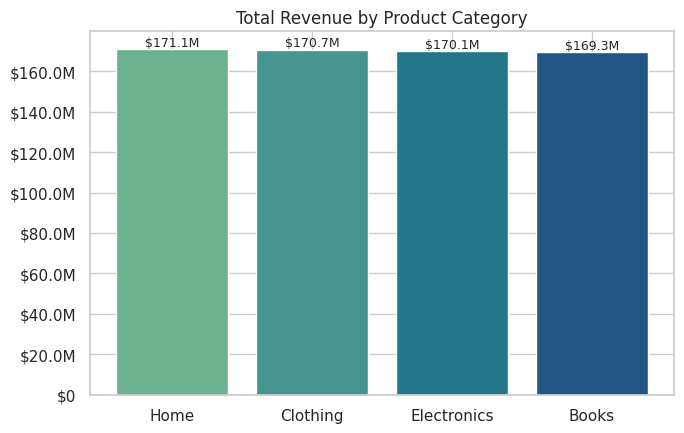

In [14]:
cat_rev = df.groupby("category")["amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4.5))
bars = plt.bar(cat_rev.index, cat_rev.values, color=sns.color_palette("crest", len(cat_rev)))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.title("Total Revenue by Product Category")
for b, v in zip(bars, cat_rev.values):
    plt.text(b.get_x()+b.get_width()/2, v, money_fmt(v, None), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


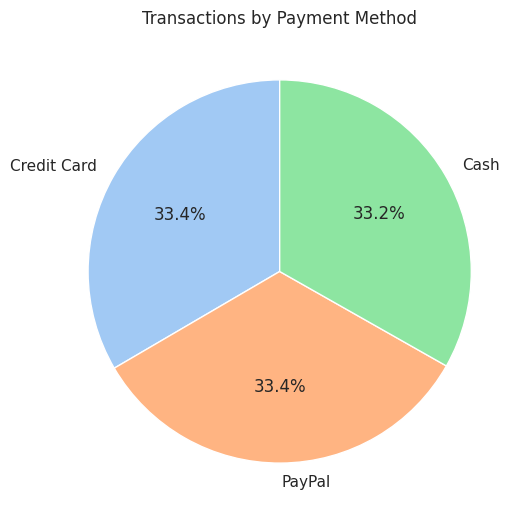

In [15]:
pm = df["payment_method"].value_counts()
plt.figure(figsize=(5.5, 5.5))
plt.pie(pm.values, labels=pm.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel", len(pm)))
plt.title("Transactions by Payment Method")
plt.tight_layout(); plt.show()


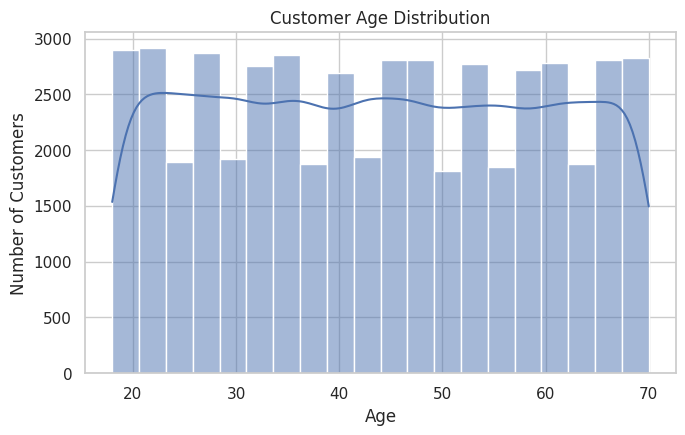

In [16]:
plt.figure(figsize=(7, 4.5))
sns.histplot(cust["age"], bins=20, kde=True, color="#4C72B0")
plt.title("Customer Age Distribution"); plt.xlabel("Age"); plt.ylabel("Number of Customers")
plt.tight_layout(); plt.show()


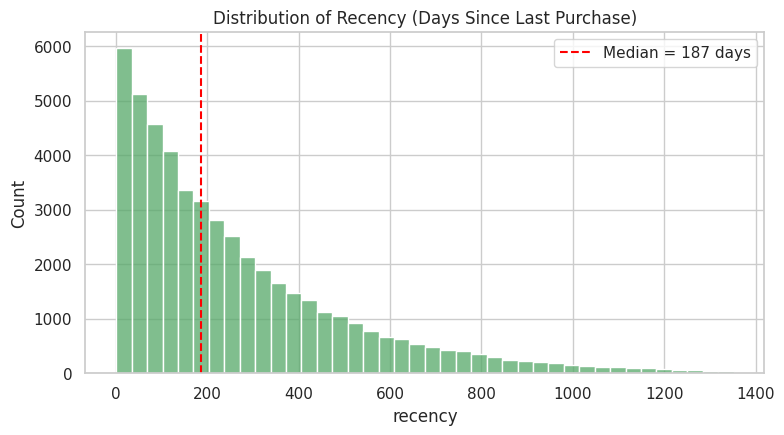

In [17]:
plt.figure(figsize=(8, 4.5))
sns.histplot(cust["recency"], bins=40, color="#55A868")
plt.axvline(cust["recency"].median(), color="red", ls="--", label=f"Median = {cust['recency'].median():.0f} days")
plt.title("Distribution of Recency (Days Since Last Purchase)")
plt.legend(); plt.tight_layout(); plt.show()


## 8. Retention & Cohort Analysis

Each customer is assigned to a monthly acquisition cohort based on their first purchase.
We then track what share of each cohort is still transacting in subsequent months.


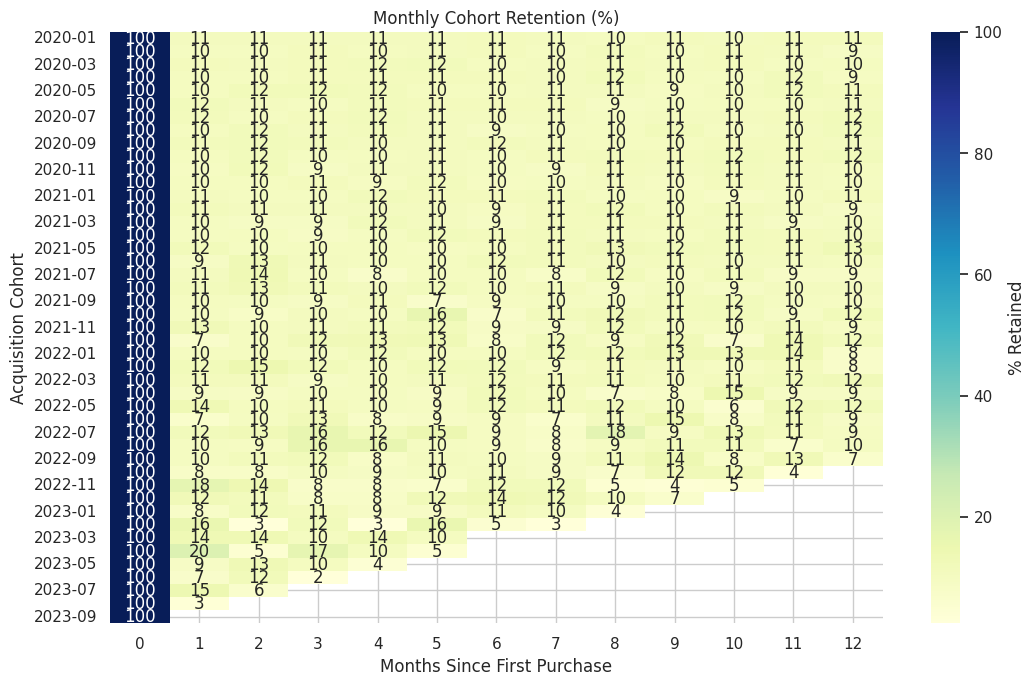

In [18]:
df["order_period"] = df["purchase_date"].dt.to_period("M")
first_purchase = df.groupby("customer_id")["order_period"].min().rename("cohort")
df2 = df.join(first_purchase, on="customer_id")
df2["period_number"] = (df2["order_period"] - df2["cohort"]).apply(lambda x: x.n)

cohort_data = df2.groupby(["cohort", "period_number"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort", columns="period_number", values="customer_id")
retention = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0) * 100
retention_display = retention.iloc[:, :13]

plt.figure(figsize=(11, 7))
sns.heatmap(retention_display, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% Retained"})
plt.title("Monthly Cohort Retention (%)"); plt.xlabel("Months Since First Purchase"); plt.ylabel("Acquisition Cohort")
plt.tight_layout(); plt.show()


**Observation:** retention flattens to roughly the same ~10–13% almost immediately after
month 0 and stays roughly flat out to month 12, rather than showing the gradual decay curve
typical of real repeat-purchase behavior. Combined with the churn-label check in Section 9,
this indicates that repeat-purchase timing in this dataset is close to randomly distributed
rather than driven by satisfaction/engagement dynamics. We report this transparently — the
*segmentation* (based on realized recency/frequency/monetary) is still valid and actionable,
but a real deployment should re-validate retention decay curves on live data.


## 9. Churn Risk Analysis

In [19]:
churn_corr = cust[["churn", "recency", "frequency", "monetary", "avg_order_value",
                    "return_rate", "tenure_days", "age"]].corr()["churn"].drop("churn")
churn_corr.round(3).sort_values()


All correlations between the provided `churn` label and behavioral features are
essentially **zero** (|r| < 0.01). We still fit a logistic regression as a rigorous check.


In [20]:
model_feats = ["recency", "frequency", "monetary", "avg_order_value", "return_rate", "tenure_days", "age"]
cat_cols = ["preferred_category", "preferred_payment", "gender"]
X_model = pd.get_dummies(cust[model_feats + cat_cols], columns=cat_cols, drop_first=True)
y_model = cust["churn"]

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.25, random_state=42, stratify=y_model)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_s, y_train)
y_prob = logreg.predict_proba(X_test_s)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(auc, 3))
print(classification_report(y_test, logreg.predict(X_test_s)))


ROC-AUC: 0.497
              precision    recall  f1-score   support

           0       0.80      0.49      0.61      9934
           1       0.20      0.51      0.29      2482

    accuracy                           0.49     12416
   macro avg       0.50      0.50      0.45     12416
weighted avg       0.68      0.49      0.54     12416



**AUC ≈ 0.50** confirms the churn label cannot be predicted from purchase behavior in this
dataset — it behaves like random noise relative to RFM features. **Business takeaway:** rather
than trusting the given `Churn` column, Alfido Tech should treat **recency-based engagement
risk** (customers going quiet for 180+ days, especially high-value ones) as the operational
churn-risk signal, since that is the one that is actually measurable and actionable.


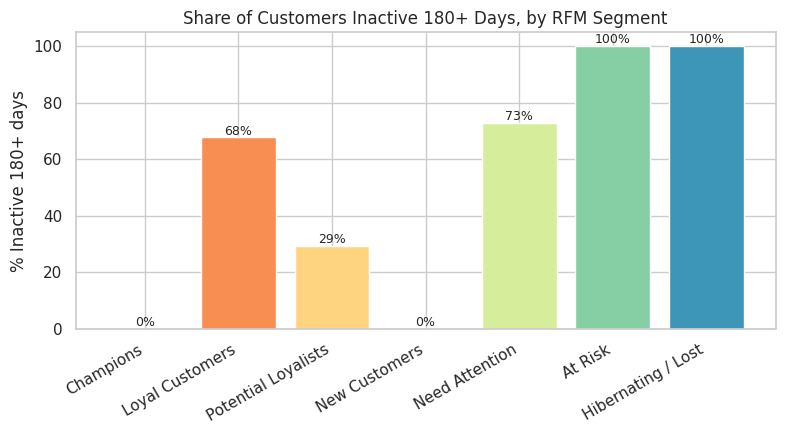

In [21]:
cust["engagement_risk"] = cust["recency"] > 180
risk_by_seg = cust.groupby("rfm_segment")["engagement_risk"].mean().reindex(SEG_ORDER) * 100
plt.figure(figsize=(8, 4.5))
bars = plt.bar(risk_by_seg.index, risk_by_seg.values, color=[PALETTE[s] for s in risk_by_seg.index])
plt.title("Share of Customers Inactive 180+ Days, by RFM Segment"); plt.ylabel("% Inactive 180+ days")
plt.xticks(rotation=30, ha="right")
for b, v in zip(bars, risk_by_seg.values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


In [22]:
at_risk_high_value = cust[cust["recency"] > 180].sort_values("monetary", ascending=False)
at_risk_high_value[["customer_id", "customer_name", "monetary", "frequency", "recency", "rfm_segment"]].head(15)


## 10. SQL Analysis Layer

The cleaned data was also loaded into a SQLite database (`alfido_customer_behavior.db`) with
a `transactions` fact table and a `customers` dimension table, and analyzed with a companion
`.sql` script (`customer_behavior_analysis.sql`) covering: data-quality checks, RFM segment
summaries, top category per segment, monthly revenue trend, cohort retention, high-value
at-risk customers, payment-method mix, return-rate by category, and a churn-label sanity check.
This mirrors the pandas analysis above in pure SQL for teams that prefer a warehouse/BI workflow.


In [23]:
import sqlite3
conn = sqlite3.connect("alfido_customer_behavior.db")  # build via build_sql.py, included alongside this notebook
cust_sql_cols = [c for c in cust.columns if c not in ("first_purchase", "last_purchase")]
cust[cust_sql_cols].to_sql("customers", conn, index=False, if_exists="replace")
tx_sql_cols = ["customer_id", "purchase_date", "category", "unit_price", "quantity",
               "amount", "payment_method", "returned", "year_month"]
df[tx_sql_cols].assign(purchase_date=df["purchase_date"].astype(str)).to_sql(
    "transactions", conn, index=False, if_exists="replace")

query = '''
SELECT rfm_segment,
       COUNT(*) AS customers,
       ROUND(AVG(recency),1) AS avg_recency,
       ROUND(SUM(monetary),2) AS total_revenue
FROM customers
GROUP BY rfm_segment
ORDER BY total_revenue DESC;
'''
pd.read_sql_query(query, conn)


## 11. Key Findings & Recommendations for Alfido Tech

### Key Findings
1. **Revenue is concentrated**: Champions + Loyal Customers are ~38% of customers but drive ~56% of revenue.
2. **A large "Hibernating / Lost" segment** (~19% of customers, ~9% of revenue) has gone quiet (avg. recency > 500 days).
3. **Electronics and Clothing dominate revenue** for the highest-value segments.
4. **The provided `Churn` label is not behaviorally predictable** (AUC ≈ 0.50, near-zero correlations) — treat it as unreliable and use recency-based engagement risk instead.
5. **Retention/cohort curves are flat** rather than decaying — worth re-validating on live production data, since this may be an artifact of the (synthetic) dataset rather than genuine customer behavior.
6. **Return rates are high and uniform (~40%) across all categories**, suggesting either a systemic fulfillment/quality issue or a data-generation artifact — worth investigating operationally either way.

### 5 Actionable Recommendations
1. **Launch a win-back campaign for high-value "At Risk" and "Can't Lose Them" customers** — targeted discounts or personal outreach to the top-spending customers inactive 180+ days (see Section 9 list) before they fully churn.
2. **Build a VIP loyalty tier for Champions & Loyal Customers** — this ~38% of customers drives over half of revenue; formal perks (early access, free shipping, loyalty points) protect this base from competitors.
3. **Automate lifecycle email/SMS flows keyed to RFM segment**, not blanket campaigns — e.g. onboarding nudges for New Customers, replenishment reminders for Potential Loyalists, reactivation offers for Hibernating customers.
4. **Investigate the ~40% return rate** with the operations/fulfillment team — even a few points of reduction meaningfully improves net revenue and customer satisfaction; segment the investigation by category and payment method.
5. **Replace the current `Churn` field with a live, behaviorally-grounded churn-risk score** (e.g. the recency + frequency + monetary risk framework built here) in production reporting/CRM, since the existing label carries no predictive signal.

---
*Companion deliverables: SQL script (`customer_behavior_analysis.sql`), Power BI data model (`Alfido_PowerBI_Data_Model.xlsx`), and PDF summary report.*
